# Cosmological Angular Power Spectra + MCMC


## 0. Imports & Setup

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from scipy.interpolate import interp1d, RectBivariateSpline
from scipy.integrate import simpson, cumulative_trapezoid
import os
from contextlib import redirect_stdout, redirect_stderr
import emcee
import corner
import h5py

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)

## 1. Configuration

In [22]:
class Config:
    COSMO_PARAMS = {
        "Omega_m": 0.315,
        "Omega_b": 0.05,
        "h": 0.67,
        "n_s": 0.96,
        "sigma8": 0.83,
        "M_nu": 0.0,
        "w0": -1.0,
        "wa": 0.0,
        "aexp": 1.0,
    }
    c = 299792.458
    Z_MIN = 0.01
    Z_MAX = 1.5
    N_Z = 500
    N_Z_CHI = 2000
    Z0_GALAXY = 0.3
    ELL_MIN = 10
    ELL_MAX = 2000
    N_ELL = 50
    BIAS_B0 = 2.0
    alpha = 2.225
    FR_VALUES = [4, 5, 6]
    BACCO_K_MIN = -2
    BACCO_K_MAX = None
    BACCO_N_K = 200
    EMANTIS_VERBOSE = False
    FIGURE_SIZE = (14, 10)
    K_MIN_SAFETY = 1.1
    K_MAX_SAFETY = 0.9

## 2. Core Functions

In [23]:
def hubble_function(z, H0, Om_m, Om_lambda):
    z = np.asarray(z)
    return H0 * np.sqrt(
        Om_m * (1 + z) ** 3
        + (1 - Om_m - Om_lambda) * (1 + z) ** 2
        + Om_lambda
    )


def build_chi_interpolator(H0, Om_m, Om_lambda, n=None):
    n = n or Config.N_Z_CHI
    z_dense = np.linspace(0.0, Config.Z_MAX * 1.05, n)
    Hz = hubble_function(z_dense, H0, Om_m, Om_lambda)
    chi_dense = np.concatenate(
        [[0.0], cumulative_trapezoid(Config.c / Hz, z_dense)]
    )
    return interp1d(z_dense, chi_dense, kind="cubic",
                    bounds_error=False, fill_value="extrapolate")


def compute_Omega_z(z, H0, Om_m, Om_lambda):
    num = Om_m * (1 + z) ** 3
    den = Om_m * (1 + z) ** 3 + (1 - Om_m - Om_lambda) * (1 + z) ** 2 + Om_lambda
    return num / den


def compute_lambda_z(z, H0, Om_m, Om_lambda):
    num = Om_lambda
    den = Om_m * (1 + z) ** 3 + (1 - Om_m - Om_lambda) * (1 + z) ** 2 + Om_lambda
    return num / den


def growth_function_g(z, H0, Om_m, Om_lambda):
    Omega_z = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lambda_z = compute_lambda_z(z, H0, Om_m, Om_lambda)
    den = Omega_z ** (4 / 7) - lambda_z + (1 + Omega_z / 2) * (1 + lambda_z / 70)
    return (5 * Omega_z / 2) * (1 / den)


def growth_factor_D(z, H0, Om_m, Om_lambda):
    z = np.asarray(z)
    g_z = growth_function_g(z, H0, Om_m, Om_lambda)
    g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
    return (g_z / (1.0 + z)) / g_0


def bias_function(z, H0, Omega_m, Omega_lambda, b0=1.0):
    D_z = growth_factor_D(z, H0, Omega_m, Omega_lambda)
    D_0 = growth_factor_D(0.0, H0, Omega_m, Omega_lambda)
    return b0 / (D_z / D_0 + 1e-30)


def cmb_lensing_kernel_vec(z_grid, z_star, H0, Om_m, Om_lambda, chi_of_z):
    Hz = hubble_function(z_grid, H0, Om_m, Om_lambda)
    prefactor = (3 * Om_m * H0 ** 2) / (2 * Config.c * Hz)
    chi_z = chi_of_z(z_grid)
    chi_star = float(chi_of_z(z_star))
    return prefactor * (1 + z_grid) * chi_z * (chi_star - chi_z) / chi_star


def galaxy_lensing_kernel_vec(z_grid, dNdz_arr, bias_arr, H0, Om_m, Om_lambda, chi_of_z):
    chi_z = chi_of_z(z_grid)
    Hz = hubble_function(z_grid, H0, Om_m, Om_lambda)
    alpha_minus1 = Config.alpha - 1.0
    f_A = alpha_minus1 * dNdz_arr
    f_B = alpha_minus1 * dNdz_arr / (chi_z + 1e-30)

    def suffix_trapz(f, z):
        ct = cumulative_trapezoid(f[::-1], z[::-1], initial=0.0)
        return ct[::-1]

    A_suffix = suffix_trapz(f_A, z_grid)
    B_suffix = suffix_trapz(f_B, z_grid)
    mag_integral = A_suffix - chi_z * B_suffix
    mu_prefactor = (3 * Om_m * H0 ** 2) / (2 * Config.c * Hz) * (1 + z_grid) * chi_z
    return bias_arr * dNdz_arr + mu_prefactor * mag_integral

In [24]:
def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)
            if k_max is None:
                k_max = np.log10(emulator.emulator["nonlinear"]["k"].max())
            k = np.logspace(k_min, k_max, num=n_k)
    return emulator, k


def initialize_emantis_emulator(verbose=False):
    return NonLinearMGBoostEmulator(verbose=verbose)


def _bacco_params(params):
    return {
        "omega_cold": params["Omega_m"] - params["Omega_b"],
        "sigma8_cold": params["sigma8"],
        "omega_baryon": params["Omega_b"],
        "ns": params["n_s"],
        "hubble": params["h"],
        "neutrino_mass": params.get("M_nu", 0.0),
        "w0": params.get("w0", -1.0),
        "wa": params.get("wa", 0.0),
    }


def _emantis_params(params, logfR0):
    return {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0,
    }


def _pk_by_aexp(pk, n_aexp, n_k):
    """Return BACCO output as shape (n_aexp, n_k)."""
    arr = np.asarray(pk)
    arr = np.squeeze(arr)

    if arr.ndim == 1:
        if n_aexp != 1 or arr.shape[0] != n_k:
            raise ValueError(f"Unexpected 1D BACCO P(k) shape {arr.shape} for n_aexp={n_aexp}, n_k={n_k}")
        return arr[None, :]

    if arr.shape == (n_aexp, n_k):
        return arr
    if arr.shape == (n_k, n_aexp):
        return arr.T
    if arr.size == n_aexp * n_k:
        return arr.reshape(n_aexp, n_k)

    raise ValueError(f"Unexpected BACCO P(k) shape {arr.shape}; expected ({n_aexp}, {n_k})")


def _boost_by_aexp_and_model(boost, n_aexp, n_model, n_k):
    """Return e-MANTIS output as shape (n_aexp, n_model, n_k)."""
    arr = np.asarray(boost)
    arr = np.squeeze(arr)

    if arr.ndim == 1:
        if n_aexp != 1 or n_model != 1 or arr.shape[0] != n_k:
            raise ValueError(f"Unexpected 1D e-MANTIS boost shape {arr.shape}")
        return arr[None, None, :]

    if arr.ndim == 2:
        if n_model == 1 and arr.shape == (n_aexp, n_k):
            return arr[:, None, :]
        if n_model == 1 and arr.shape == (n_k, n_aexp):
            return arr.T[:, None, :]
        if n_aexp == 1 and arr.shape == (n_model, n_k):
            return arr[None, :, :]
        if n_aexp == 1 and arr.shape == (n_k, n_model):
            return arr.T[None, :, :]

    if arr.shape == (n_aexp, n_model, n_k):
        return arr
    if arr.shape == (n_model, n_aexp, n_k):
        return np.transpose(arr, (1, 0, 2))
    if arr.size == n_aexp * n_model * n_k:
        return arr.reshape(n_aexp, n_model, n_k)

    raise ValueError(
        f"Unexpected e-MANTIS boost shape {arr.shape}; expected ({n_aexp}, {n_model}, {n_k})"
    )


def _build_logpk_spline_from_pk2d(k, z_grid, pk_2d):
    log_k = np.log(k)
    return RectBivariateSpline(log_k, z_grid, np.log(pk_2d + 1e-50), kx=3, ky=3)


def predict_bacco_pk_grid(emulator, params, k, z_grid):
    """Vectorized BACCO call over all redshifts/scale factors."""
    bp = _bacco_params(params)
    aexp_grid = 1.0 / (1.0 + np.asarray(z_grid))

    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            _, pk_nl = emulator.get_nonlinear_pk(
                k=k,
                cold=False,
                expfactor=aexp_grid,
                **bp,
            )

    return _pk_by_aexp(pk_nl, n_aexp=len(aexp_grid), n_k=len(k))


def build_pk_spline_gr(emulator, params, k, z_grid):
    pk_by_z = predict_bacco_pk_grid(emulator, params, k, z_grid)
    return _build_logpk_spline_from_pk2d(k, z_grid, pk_by_z.T)


def build_pk_spline_fr(emulator, emantis_emu, params, logfR0, k, z_grid):
    pk_gr_by_z = predict_bacco_pk_grid(emulator, params, k, z_grid)
    aexp_grid = 1.0 / (1.0 + np.asarray(z_grid))
    ep = _emantis_params(params, logfR0)

    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            boost = emantis_emu.predict_boost(
                ep,
                aexp=aexp_grid,
                k=k,
                squeeze=False,
            )

    boost_by_z = _boost_by_aexp_and_model(boost, n_aexp=len(aexp_grid), n_model=1, n_k=len(k))[:, 0, :]
    pk_fr_by_z = pk_gr_by_z * boost_by_z
    return _build_logpk_spline_from_pk2d(k, z_grid, pk_fr_by_z.T)


def build_pk_splines_fr_many(emulator, emantis_emu, params, logfR0_values, k, z_grid):
    """Vectorized BACCO over z and vectorized e-MANTIS over both z and f(R) values."""
    logfR0_values = list(logfR0_values)
    pk_gr_by_z = predict_bacco_pk_grid(emulator, params, k, z_grid)
    aexp_grid = 1.0 / (1.0 + np.asarray(z_grid))

    ep_many = {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0_values,
    }

    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            boost = emantis_emu.predict_boost(
                ep_many,
                aexp=aexp_grid,
                k=k,
                squeeze=False,
            )

    boost_by_z_model = _boost_by_aexp_and_model(
        boost,
        n_aexp=len(aexp_grid),
        n_model=len(logfR0_values),
        n_k=len(k),
    )

    splines = {}
    for i, logfR0 in enumerate(logfR0_values):
        pk_fr_by_z = pk_gr_by_z * boost_by_z_model[:, i, :]
        splines[logfR0] = _build_logpk_spline_from_pk2d(k, z_grid, pk_fr_by_z.T)
    return splines


def compute_Cl_vec(ell_array, pk_spline, z_grid, Wg_vals, Wkappa_vals,
                   chi_vals, H_vals, h, c_light, k_min=None, k_max=None, cross=False):
    chi_h = chi_vals * h
    k_vals = (ell_array[:, None] + 0.5) / chi_h[None, :]
    if k_min is not None:
        k_vals = np.clip(k_vals, k_min, k_max)
    log_P_flat = pk_spline(
        np.log(k_vals).ravel(), np.tile(z_grid, len(ell_array)), grid=False
    )
    P_kz = np.exp(log_P_flat).reshape(len(ell_array), len(z_grid)) / h ** 3
    W_product = (Wkappa_vals * Wg_vals)[None, :] if cross else Wg_vals[None, :] ** 2
    integrand = (H_vals[None, :] / c_light) * W_product * P_kz / chi_vals[None, :] ** 2
    return simpson(integrand, z_grid, axis=1)

## 3. Caching Helpers & MCMC Model

In [25]:
_ROUND = 5
_geo_cache = {}
_pk_cache = {}
_GEO_MAXSIZE = 128
_PK_MAXSIZE = 128


def _evict(cache, maxsize):
    if len(cache) >= maxsize:
        del cache[next(iter(cache))]


def get_geometry(Omega_m, b0, z_grid_local, z_star):
    key = (round(float(Omega_m), _ROUND), round(float(b0), _ROUND))
    if key in _geo_cache:
        return _geo_cache[key]
    H0_loc = Config.COSMO_PARAMS["h"] * 100.0
    Om_m_loc = float(Omega_m)
    Om_lam_loc = 1.0 - Om_m_loc
    chi_of_z_loc = build_chi_interpolator(H0_loc, Om_m_loc, Om_lam_loc)
    chi_loc = chi_of_z_loc(z_grid_local)
    H_loc = hubble_function(z_grid_local, H0_loc, Om_m_loc, Om_lam_loc)
    raw_nz = (2.0 * Config.Z0_GALAXY) * (z_grid_local / Config.Z0_GALAXY) ** 2 \
             * np.exp(-z_grid_local / Config.Z0_GALAXY)
    dNdz_loc = raw_nz / simpson(raw_nz, z_grid_local)
    Wkap_loc = cmb_lensing_kernel_vec(z_grid_local, z_star, H0_loc, Om_m_loc, Om_lam_loc, chi_of_z_loc)
    bias_loc = bias_function(z_grid_local, H0_loc, Om_m_loc, Om_lam_loc, b0=float(b0))
    Wg_loc = galaxy_lensing_kernel_vec(z_grid_local, dNdz_loc, bias_loc, H0_loc, Om_m_loc, Om_lam_loc, chi_of_z_loc)
    result = dict(H0=H0_loc, Om_m=Om_m_loc, Om_lam=Om_lam_loc,
                  chi=chi_loc, H=H_loc, Wkappa=Wkap_loc, Wg=Wg_loc)
    _evict(_geo_cache, _GEO_MAXSIZE)
    _geo_cache[key] = result
    return result


def get_pk_spline(Omega_m, sigma8, logfR0, z_grid_local, bacco_emu, emantis_emu, k):
    key = (round(float(Omega_m), _ROUND), round(float(sigma8), _ROUND), round(float(logfR0), _ROUND))
    if key in _pk_cache:
        return _pk_cache[key]
    params = Config.COSMO_PARAMS.copy()
    params["Omega_m"] = float(Omega_m)
    params["sigma8"] = float(sigma8)
    spline = build_pk_spline_fr(bacco_emu, emantis_emu, params, abs(float(logfR0)), k, z_grid_local)
    _evict(_pk_cache, _PK_MAXSIZE)
    _pk_cache[key] = spline
    return spline


def model_cls_fast(theta, ell_local, z_grid_local, z_star, bacco_emu, emantis_emu, k, k_min_safe, k_max_safe):
    Omega_m, sigma8, b0, logfR0 = theta
    geo = get_geometry(Omega_m, b0, z_grid_local, z_star)
    spline = get_pk_spline(Omega_m, sigma8, logfR0, z_grid_local, bacco_emu, emantis_emu, k)
    shared_kw = dict(
        z_grid=z_grid_local,
        Wg_vals=geo["Wg"], Wkappa_vals=geo["Wkappa"],
        chi_vals=geo["chi"], H_vals=geo["H"],
        h=Config.COSMO_PARAMS["h"], c_light=Config.c,
        k_min=k_min_safe, k_max=k_max_safe,
    )
    Cl_gg = compute_Cl_vec(ell_local, spline, cross=False, **shared_kw)
    Cl_kg = compute_Cl_vec(ell_local, spline, cross=True, **shared_kw)
    return Cl_gg, Cl_kg


def flatten_cls(Cl_gg, Cl_kg):
    return np.concatenate([Cl_gg, Cl_kg])

In [26]:
PLOT_OUTPUT_DIR = "mcmc_plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

H0 = Config.COSMO_PARAMS["h"] * 100.0
Om_m = Config.COSMO_PARAMS["Omega_m"]
Om_lambda = 1.0 - Om_m
z_star = 1100.0

In [27]:
bacco_emu, k = initialize_bacco_emulator(Config.COSMO_PARAMS, k_min=Config.BACCO_K_MIN, k_max=Config.BACCO_K_MAX, n_k=Config.BACCO_N_K, verbose=Config.EMANTIS_VERBOSE)

In [28]:
emantis_emu = initialize_emantis_emulator(verbose=Config.EMANTIS_VERBOSE)

k_min_safe = k.min() * Config.K_MIN_SAFETY
k_max_safe = k.max() * Config.K_MAX_SAFETY

In [29]:
z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)


In [30]:
chi_of_z = build_chi_interpolator(H0, Om_m, Om_lambda)
chi_vals = chi_of_z(z_grid)
H_vals = hubble_function(z_grid, H0, Om_m, Om_lambda)

_raw_nz = (2.0 * Config.Z0_GALAXY) * (z_grid / Config.Z0_GALAXY) ** 2 \
          * np.exp(-z_grid / Config.Z0_GALAXY)
dNdz = _raw_nz / simpson(_raw_nz, z_grid)

Wkappa_vals = cmb_lensing_kernel_vec(z_grid, z_star, H0, Om_m, Om_lambda, chi_of_z)
bias_arr = bias_function(z_grid, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)
Wg_vals = galaxy_lensing_kernel_vec(z_grid, dNdz, bias_arr, H0, Om_m, Om_lambda, chi_of_z)


In [31]:
pk_spline_gr = build_pk_spline_gr(bacco_emu, Config.COSMO_PARAMS, k, z_grid)

In [32]:
ell = np.logspace(np.log10(Config.ELL_MIN), np.log10(Config.ELL_MAX), Config.N_ELL)
shared = dict(
    z_grid=z_grid, Wg_vals=Wg_vals, Wkappa_vals=Wkappa_vals,
    chi_vals=chi_vals, H_vals=H_vals, h=Config.COSMO_PARAMS["h"],
    c_light=Config.c, k_min=k_min_safe, k_max=k_max_safe,
)


In [33]:
Cl_gg_gr = compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)
Cl_kg_gr = compute_Cl_vec(ell, pk_spline_gr, cross=True, **shared)

In [34]:
fr_results = {"gg": {}, "kg": {}}
pk_splines_fr = build_pk_splines_fr_many(
    bacco_emu,
    emantis_emu,
    Config.COSMO_PARAMS,
    Config.FR_VALUES,
    k,
    z_grid,
)

for logfR0_val, pk_spline_fr in pk_splines_fr.items():
    fr_results["gg"][logfR0_val] = compute_Cl_vec(ell, pk_spline_fr, cross=False, **shared)
    fr_results["kg"][logfR0_val] = compute_Cl_vec(ell, pk_spline_fr, cross=True, **shared)

## 12. Plot Power Spectra

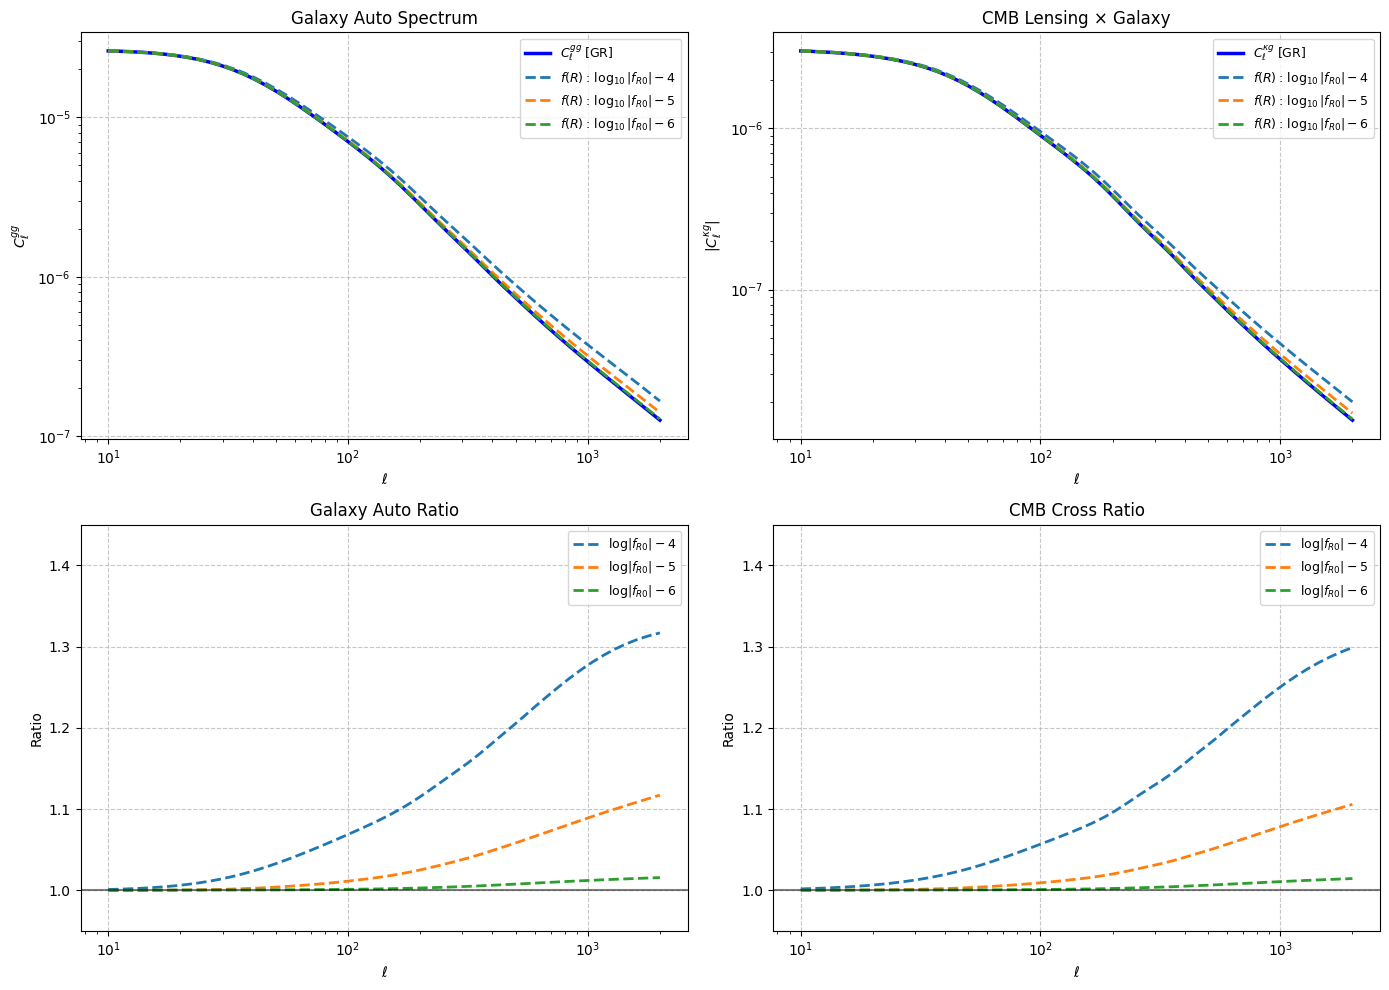

In [35]:
def plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr, fr_results=None,
                       fR_values=None, figsize=(14, 10)):
    fig = plt.figure(figsize=figsize)

    plt.subplot(2, 2, 1)
    plt.loglog(ell, Cl_gg_gr, "b-", linewidth=2.5, label=r"$C_\ell^{gg}\;[\mathrm{GR}]$")
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["gg"]:
                plt.loglog(ell, fr_results["gg"][v], "--", linewidth=2,
                           label=rf"$f(R):\,\log_{{10}}|f_{{R0}}|-{v}$")
    plt.xlabel(r"$\ell$"); plt.ylabel(r"$C_\ell^{gg}$")
    plt.title(r"Galaxy Auto Spectrum"); plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7)

    plt.subplot(2, 2, 2)
    plt.loglog(ell, np.abs(Cl_kg_gr), "b-", linewidth=2.5, label=r"$C_\ell^{\kappa g}\;[\mathrm{GR}]$")
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["kg"]:
                plt.loglog(ell, np.abs(fr_results["kg"][v]), "--", linewidth=2,
                           label=rf"$f(R):\,\log_{{10}}|f_{{R0}}|-{v}$")
    plt.xlabel(r"$\ell$"); plt.ylabel(r"$|C_\ell^{\kappa g}|$")
    plt.title(r"CMB Lensing × Galaxy"); plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7)

    plt.subplot(2, 2, 3)
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["gg"]:
                plt.semilogx(ell, fr_results["gg"][v] / Cl_gg_gr, "--", linewidth=2,
                             label=rf"$\log|f_{{R0}}|-{v}$")
        plt.axhline(1.0, color="k", lw=1.5, alpha=0.5)
    plt.xlabel(r"$\ell$"); plt.ylabel(r"Ratio"); plt.title(r"Galaxy Auto Ratio")
    plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7); plt.ylim([0.95, 1.45])

    plt.subplot(2, 2, 4)
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["kg"]:
                plt.semilogx(ell, fr_results["kg"][v] / Cl_kg_gr, "--", linewidth=2,
                             label=rf"$\log|f_{{R0}}|-{v}$")
        plt.axhline(1.0, color="k", lw=1.5, alpha=0.5)
    plt.xlabel(r"$\ell$"); plt.ylabel(r"Ratio"); plt.title(r"CMB Cross Ratio")
    plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7); plt.ylim([0.95, 1.45])

    plt.tight_layout()
    return fig


fig = plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr,
                         fr_results=fr_results, fR_values=Config.FR_VALUES,
                         figsize=Config.FIGURE_SIZE)
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "power_spectra_gr_vs_fr.png"), dpi=300, bbox_inches="tight")
plt.show()